In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog
from skimage import exposure

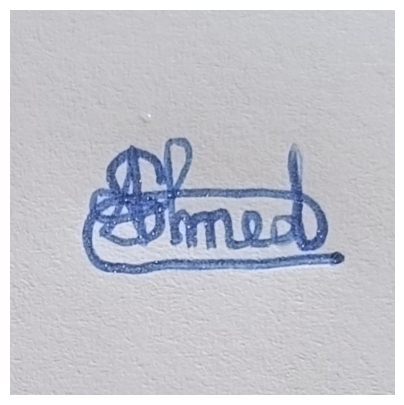

In [4]:
imagePath = 'signature.jpg'  # Replace with your image path
# imagePath = 'image-0-13.jpg'  # Replace with your image path

# Load image from path
image = cv2.imread(imagePath)

# Show the original image
plt.figure(figsize=(5, 5))
# Convert BGR to RGB for correct display
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

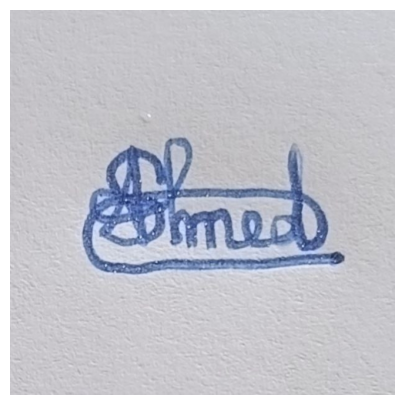

In [5]:

# Resize image to the target size
image_resized = cv2.resize(image, (500, 500))

# Show the resized image
plt.figure(figsize=(5, 5))
# Convert BGR to RGB for correct display
plt.imshow(cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

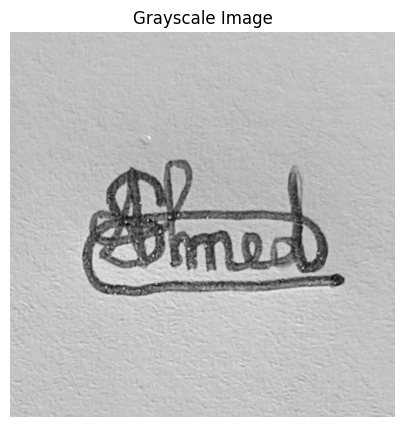

In [6]:
# Convert image to grayscale
gray_image = cv2.cvtColor(image_resized, cv2.COLOR_BGR2GRAY)

# Show the grayscale image
plt.figure(figsize=(5, 5))
plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

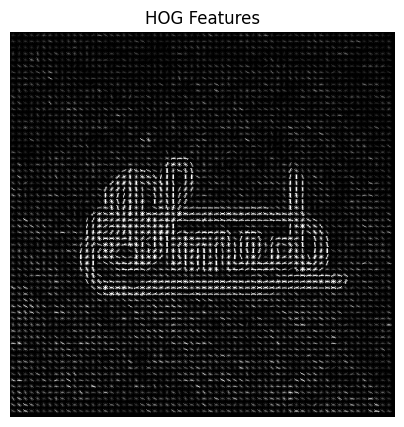

In [7]:
# Extract HOG features and visualize the HOG image
features, hog_image = hog(gray_image, block_norm='L2-Hys', pixels_per_cell=(8, 8),
                            cells_per_block=(2, 2), visualize=True)

# Rescale the HOG image for better visualization
hog_image_rescaled = exposure.rescale_intensity(
    hog_image, in_range=(0, 10))

# Show the HOG image
plt.figure(figsize=(5, 5))
plt.imshow(hog_image_rescaled, cmap='gray')
plt.title("HOG Features")
plt.axis('off')
plt.show()

In [8]:
features

array([0.24329965, 0.03779249, 0.15536342, ..., 0.25527486, 0.26386435,
       0.09828931], shape=(133956,))

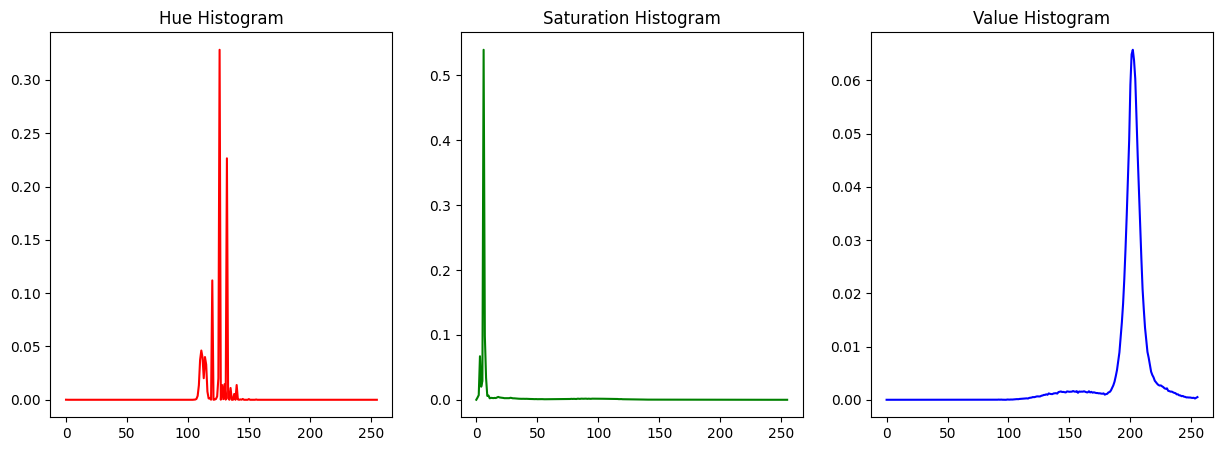

In [9]:
# Convert to HSV color space
hsv_image = cv2.cvtColor(image_resized, cv2.COLOR_BGR2HSV)

# Calculate histograms for each channel (Hue, Saturation, Value)
hue = cv2.calcHist([hsv_image], [0], None, [256], [0, 256])
saturation = cv2.calcHist([hsv_image], [1], None, [256], [0, 256])
value = cv2.calcHist([hsv_image], [2], None, [256], [0, 256])

# Normalize histograms
hue /= hue.sum()
saturation /= saturation.sum()
value /= value.sum()

# Show the histograms
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(hue, color='r')
plt.title("Hue Histogram")

plt.subplot(1, 3, 2)
plt.plot(saturation, color='g')
plt.title("Saturation Histogram")

plt.subplot(1, 3, 3)
plt.plot(value, color='b')
plt.title("Value Histogram")

plt.show()

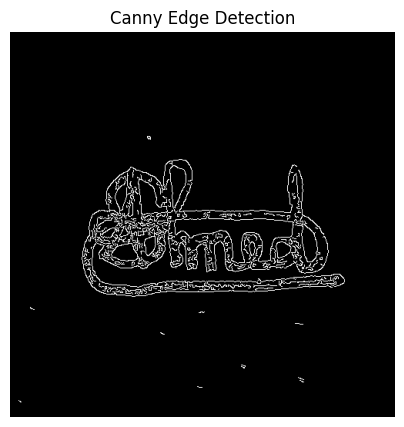

In [10]:
# Apply Canny edge detection
edges = cv2.Canny(gray_image, threshold1=100, threshold2=200)

# Show the edge-detected image
plt.figure(figsize=(5, 5))
plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis('off')
plt.show()